# Artificial Neural Network (ANN) - California Housing Price Prediction

Design and implement a basic ANN using California Housing tabular dataset.
Implements data preprocessing, ANN architecture, training, and evaluation.


---



In [27]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [28]:
housing = fetch_california_housing()
X, y = housing.data, housing.target.reshape(-1, 1)

The dataset has no missing values, so no handling was required.

No Encoding because all features are numerical.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [31]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(8,)),
    Dropout(0.1),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='linear')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

In [33]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [34]:
history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5526 - val_loss: 0.3515
Epoch 2/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3331 - val_loss: 0.3147
Epoch 3/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3018 - val_loss: 0.2808
Epoch 4/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2682 - val_loss: 0.2676
Epoch 5/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2665 - val_loss: 0.2632
Epoch 6/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2542 - val_loss: 0.2550
Epoch 7/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2587 - val_loss: 0.2580
Epoch 8/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2458 - val_loss: 0.2517
Epoch 9/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2400 - val_loss: 0.2393
Epoch 10/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2402 - val_loss: 0.2475
Epoch 11/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2341 - val_loss: 0.2408
Epoch 12/200
413/413 ━━━━━━━━━━━━━━━━━━━━

In [39]:
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

test_mse = mean_squared_error(y_test, y_pred)

print(f"Test MSE: {test_mse:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test MSE: 0.2632


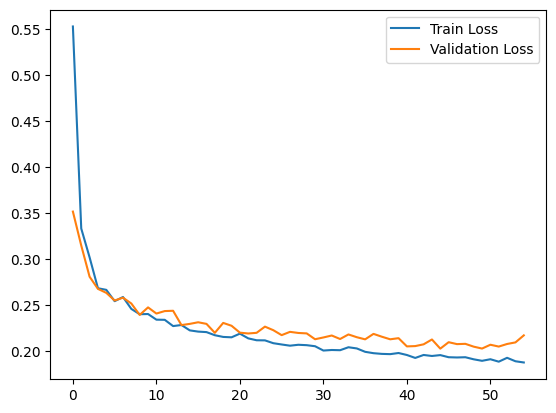

In [41]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

# Explaination

1. **ANN Architecture**:

- Input Layer: 8 neurons (for 8 features from California Housing dataset)
- Hidden Layer 1: 128 neurons, ReLU activation
- Dropout Layer: 10% dropout to prevent overfitting
- Hidden Layer 2: 64 neurons, ReLU activation
- Dropout Layer: 10% dropout
- Output Layer: 1 neuron, Linear activation (for regression output)

Summary:
- The input layer receives features.
- Hidden layers extract non-linear patterns.
- Dropout layers reduce overfitting.
- Output layer predicts continuous house price values.

------------------------------------------------------------

2. **Activation Functions**:

- ReLU (Rectified Linear Unit) in hidden layers:
    f(x) = max(0, x)
    - Introduces non-linearity
    - Avoids vanishing gradients
    - Efficient for training deep networks

- Linear activation in output layer:
    f(x) = x
    - Suitable for regression tasks
    - Outputs continuous values

------------------------------------------------------------

3. **Loss Function and Optimizer**:

- Loss Function: Mean Squared Error (MSE)
    MSE = (1/n) * Σ(y_true - y_pred)^2
    - Measures average squared difference between predicted and actual values
    - Standard for regression
    - Penalizes large errors more strongly

- Optimizer: Adam
    - Combines momentum and adaptive learning rates
    - Fast and stable convergence
    - Works well for most neural network tasks

------------------------------------------------------------